# Domain Adaptation — Adapted CNN, CORAL + Random Forest, and Full Comparison

Builds adaptation methods on top of the baselines from `model_training.ipynb`, then tabulates everything together for all 12 ordered (source_load, target_load) pairs:

1. **Adapted CNN (fine-tuned from Baseline 1)** — loads Baseline 1's source-trained weights and retrains on the target domain's scarce labeled subset at a lower learning rate, in two freeze variants:
   - **full**: freeze the entire `embedding_extractor`, retrain only `label_predictor`.
   - **partial**: freeze everything except the last conv block, which is unfrozen (weights *and* BatchNorm running stats) alongside `label_predictor`.
2. **Adapted classical ML (CORAL + Random Forest)** — CORAL-aligns `source_train` to `target_labeled`'s covariance, then trains a Random Forest on the result, run on **three** feature sets: `features_fault_freq.npz` (9-dim, no reduction needed), and `features_fft.npz`/`features_envelope.npz` (2049-dim each — first reduced via PCA, since the covariance math needed for CORAL would otherwise be severely rank-deficient against as few as 56 target samples).
3. **Full comparison** — all methods above vs. both baselines, evaluated on the same `target_test`, for all 12 pairs.

**Design choices carried over from `model_training.ipynb` for a fair comparison:** Baseline 2, every adaptation method's target-side data, and CORAL's target-side statistics all use the *exact same* scarce 10%/class window subset per load (same seed, same selection logic). A sanity check below re-derives Baseline 2's numbers from that subset and confirms they closely match `baseline_results.csv` (small residual differences are GPU/cuDNN training non-determinism, not a data-selection bug).

**All trained models are saved to `models/`** (project root, not `data/`) — 8 baseline checkpoints (from `model_training.ipynb`), 24 adapted-CNN checkpoints (2 freeze modes × 12 pairs), and 36 CORAL+RF bundles (3 feature sets × 12 pairs, each a joblib dump of `{clf, scaler, pca}`).

In [1]:
import os
import pickle
import random
from collections import defaultdict
from itertools import permutations

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report

DATA_DIR = "data"
MODELS_DIR = "models"  # project-root-relative, sibling of data/ — matches model_training.ipynb
os.makedirs(MODELS_DIR, exist_ok=True)
WINDOW_SIZE = 4096
SEED = 42
TARGET_LABELED_FRAC = 0.10  # must match model_training.ipynb's baseline 2, for a fair comparison
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

with open(os.path.join(DATA_DIR, "windows_by_load.pkl"), "rb") as f:
    windows_by_load = pickle.load(f)

LOADS = sorted(windows_by_load.keys())
baseline_results = pd.read_csv(os.path.join(DATA_DIR, "baseline_results.csv"))


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

Using device: cuda


## Labels and model architecture

Identical to `model_training.ipynb` (redefined here rather than imported, matching this project's one-notebook-per-stage convention) — needed to load the saved checkpoints into matching model instances.

In [2]:
def label_for_item(item):
    if item["category"] == "normal":
        return "normal"
    return f"{item['fault_location']}_{item['fault_diameter_in']:.3f}"


CLASS_NAMES = sorted({
    label_for_item(item)
    for load_windows in windows_by_load.values()
    for items in load_windows.values()
    for item in items
})
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
N_CLASSES = len(CLASS_NAMES)
print(f"{N_CLASSES} classes: {CLASS_NAMES}")


class WindowDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        x = torch.tensor(item["window"], dtype=torch.float32).unsqueeze(0)
        y = CLASS_TO_IDX[label_for_item(item)]
        return x, y


def class_weights(items, device=DEVICE):
    counts = np.zeros(N_CLASSES)
    for item in items:
        counts[CLASS_TO_IDX[label_for_item(item)]] += 1
    weights = counts.sum() / (N_CLASSES * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device)


class EmbeddingExtractor(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=16, padding=24), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, embedding_dim)

    def forward(self, x):
        x = self.conv(x).squeeze(-1)
        return self.fc(x)


class LabelPredictor(nn.Module):
    def __init__(self, embedding_dim=128, n_classes=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, z):
        return self.net(z)


class CNNClassifier(nn.Module):
    def __init__(self, embedding_dim=128, n_classes=N_CLASSES):
        super().__init__()
        self.embedding_extractor = EmbeddingExtractor(embedding_dim)
        self.label_predictor = LabelPredictor(embedding_dim, n_classes)

    def forward(self, x):
        return self.label_predictor(self.embedding_extractor(x))


@torch.no_grad()
def evaluate_model(model, items, device=DEVICE, batch_size=32):
    model.eval()
    loader = DataLoader(WindowDataset(items), batch_size=batch_size)
    y_true, y_pred = [], []
    for x, y in loader:
        preds = model(x.to(device)).argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }

10 classes: ['ball_0.007', 'ball_0.014', 'ball_0.021', 'inner_race_0.007', 'inner_race_0.014', 'inner_race_0.021', 'normal', 'outer_race_0.007', 'outer_race_0.014', 'outer_race_0.021']


## The shared scarce target subset

Re-derives the *same* 10%/class subset indices `model_training.ipynb` used for baseline 2 — same seed, same per-class grouping logic, applied to the same `windows_by_load[load]["train"]` lists. Returning **indices** (not the shuffled items themselves) lets the same selection be applied both to `windows_by_load` (raw windows, for the CNN) and to `features_fault_freq.npz` (pre-extracted features, for CORAL) — the two are guaranteed to be in matching order because both were built by iterating `windows_by_load` in the same fixed order.

In [3]:
def subsample_indices_per_class(items, frac, seed=SEED, min_per_class=1):
    """Indices into `items` for a deterministic, per-class proportional subsample."""
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for idx, item in enumerate(items):
        by_class[label_for_item(item)].append(idx)

    selected = []
    for idx_list in by_class.values():
        idx_list = idx_list.copy()
        rng.shuffle(idx_list)
        n_keep = min(len(idx_list), max(min_per_class, round(len(idx_list) * frac)))
        selected.extend(idx_list[:n_keep])
    return selected


# Computed once per load (not per pair) — same efficiency pattern as model_training.ipynb
scarce_indices_by_load = {
    load: subsample_indices_per_class(windows_by_load[load]["train"], TARGET_LABELED_FRAC)
    for load in LOADS
}
target_labeled_by_load = {
    load: [windows_by_load[load]["train"][i] for i in scarce_indices_by_load[load]]
    for load in LOADS
}
for load in LOADS:
    print(f"load={load}: {len(target_labeled_by_load[load])} scarce target_labeled windows")

load=0: 56 scarce target_labeled windows
load=1: 131 scarce target_labeled windows
load=2: 134 scarce target_labeled windows
load=3: 133 scarce target_labeled windows


In [4]:
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3


def train_model(model, train_items, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=DEVICE):
    model.to(device)
    train_loader = DataLoader(WindowDataset(train_items), batch_size=min(batch_size, len(train_items)), shuffle=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights(train_items, device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()


# Sanity check: retrain a model from scratch on target_labeled_by_load, using the exact same recipe
# model_training.ipynb used for baseline 2, and confirm the accuracy matches baseline_results.csv.
# This validates subsample_indices_per_class actually selects the same windows the original
# subsample_frac_per_class did — not just that it selects the same *count* per class.
print(f"{'load':<6}{'n_scarce':<10}{'recomputed_acc':<16}{'csv_acc':<10}")
for load in LOADS:
    set_seed(SEED)
    model = CNNClassifier()
    train_model(model, target_labeled_by_load[load])
    eval_result = evaluate_model(model, windows_by_load[load]["test"])

    expected = baseline_results.loc[baseline_results["target_load"] == load, "baseline2_target_scarce_acc"].iloc[0]
    print(f"{load:<6}{len(target_labeled_by_load[load]):<10}{eval_result['accuracy']:<16.3f}{expected:<10.3f}")

load  n_scarce  recomputed_acc  csv_acc   


0     56        0.906           0.906     


1     131       0.814           0.814     


2     134       0.845           0.839     


3     133       0.755           0.752     


## 1. Adapted CNN — fine-tuned from Baseline 1

Load Baseline 1's source-trained weights for `source_load`, then fine-tune on `target_labeled_by_load[target_load]` (the same scarce subset baseline 2 used) at a lower learning rate, in two freeze variants:

- **full**: freeze the entire `embedding_extractor` (weights + BatchNorm running stats), retrain only `label_predictor`. The conservative choice — with as few as ~1 example for some classes at load 0, there's little margin to re-learn convolutional filters without overfitting.
- **partial**: same, but the last conv block (`conv[8:11]`: `Conv1d → BatchNorm1d → ReLU`, the block right before `AdaptiveAvgPool1d`) is also unfrozen — both its weights *and* its BatchNorm running stats update during fine-tuning, since a block whose weights are being nudged toward the target domain shouldn't keep normalizing against stale source-domain activation statistics.

Both variants use the same fine-tuning learning rate (`FINETUNE_LR`) for whatever's unfrozen; a separately-tuned, even-lower rate for the unfrozen conv block vs. the head is a reasonable refinement not implemented here.

In [5]:
FINETUNE_EPOCHS = 30
FINETUNE_LR = 1e-4  # 10x lower than the original 1e-3
LAST_CONV_BLOCK = slice(8, 11)  # embedding_extractor.conv[8:11] = Conv1d, BatchNorm1d, ReLU


def load_baseline1_model(source_load):
    model = CNNClassifier().to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"baseline1_full_load{source_load}.pt")))
    return model


def freeze_backbone(model, mode):
    """mode='full': freeze all of embedding_extractor. mode='partial': also unfreeze the last conv block."""
    for p in model.embedding_extractor.parameters():
        p.requires_grad = False
    model.embedding_extractor.eval()

    if mode == "partial":
        last_block = model.embedding_extractor.conv[LAST_CONV_BLOCK]
        for p in last_block.parameters():
            p.requires_grad = True
    return model


def _set_train_eval_modes(model, mode):
    """Re-assert every epoch: only the head (and, in partial mode, the last conv block) stay trainable."""
    model.label_predictor.train()
    model.embedding_extractor.eval()
    if mode == "partial":
        model.embedding_extractor.conv[LAST_CONV_BLOCK].train()


def fine_tune_model(model, target_items, mode, epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, device=DEVICE):
    freeze_backbone(model, mode)

    trainable_params = list(model.label_predictor.parameters())
    if mode == "partial":
        trainable_params += list(model.embedding_extractor.conv[LAST_CONV_BLOCK].parameters())

    loader = DataLoader(WindowDataset(target_items), batch_size=min(32, len(target_items)), shuffle=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights(target_items, device))
    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    for _ in range(epochs):
        _set_train_eval_modes(model, mode)
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model

In [6]:
FREEZE_MODES = ["full", "partial"]
adapted_cnn_eval = {}  # (mode, source_load, target_load) -> eval dict

for mode in FREEZE_MODES:
    for source_load, target_load in permutations(LOADS, 2):
        set_seed(SEED)
        model = load_baseline1_model(source_load)
        fine_tune_model(model, target_labeled_by_load[target_load], mode)
        eval_result = evaluate_model(model, windows_by_load[target_load]["test"])
        adapted_cnn_eval[(mode, source_load, target_load)] = eval_result

        torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"adapted_cnn_{mode}_{source_load}to{target_load}.pt"))
        print(f"[{mode}] {source_load}->{target_load}: acc={eval_result['accuracy']:.3f} f1={eval_result['macro_f1']:.3f}")

[full] 0->1: acc=0.699 f1=0.596


[full] 0->2: acc=0.758 f1=0.662


[full] 0->3: acc=0.680 f1=0.582


[full] 1->0: acc=0.602 f1=0.493


[full] 1->2: acc=0.922 f1=0.857


...

[partial] 2->1: acc=0.904 f1=0.842


[partial] 2->3: acc=0.981 f1=0.974


[partial] 3->0: acc=0.648 f1=0.493


[partial] 3->1: acc=0.891 f1=0.821


[partial] 3->2: acc=1.000 f1=1.000


## 2. Adapted classical ML — CORAL + Random Forest

CORAL (Sun, Feng & Saenko, 2016 — "Return of Frustratingly Easy Domain Adaptation") whitens `source_train`'s features against its own covariance, then re-colors them with `target_labeled`'s covariance, so a classifier trained on the aligned source features sees roughly the same feature geometry it will meet at test time on `target_test` — without ever touching `target_test`. Random Forest over SVM: no kernel/scaling tuning needed across pairs.

Run on **three** feature sets:

- **`features_fault_freq.npz`** (9-dim BPFO/BPFI/BSF harmonic peaks) — used as-is, no reduction needed.
- **`features_fft.npz`** / **`features_envelope.npz`** (2049-dim each) — reduced to 20 components via PCA (fit on `source_train`) before CORAL. Without this, CORAL's covariance estimation would be severely rank-deficient: `target_labeled` has as few as 56 samples for load 0, nowhere near enough to estimate a well-conditioned 2049×2049 covariance matrix (the eigendecomposition would be dominated by near-zero eigenvalues from directions with no sample support, which the `eps` regularization alone can't fix at that scale). PCA sidesteps this by estimating covariance/CORAL in a much lower-dimensional space instead.

In [7]:
FEATURE_SETS = {
    "fault_freq": {"n_pca_components": None},
    "fft": {"n_pca_components": 20},
    "envelope": {"n_pca_components": 20},
}

feature_data = {}  # name -> (npz, labels)

for name in FEATURE_SETS:
    npz = np.load(os.path.join(DATA_DIR, f"features_{name}.npz"), allow_pickle=True)
    labels = np.array([
        "normal" if cat == "normal" else f"{loc}_{diam:.3f}"
        for cat, loc, diam in zip(npz["category"], npz["fault_location"], npz["fault_diameter_in"])
    ])
    feature_data[name] = (npz, labels)

    # Sanity check: row counts must match windows_by_load exactly, or the index-based scarce subset
    # (built for windows_by_load) wouldn't select the same windows when applied to this array.
    for load in LOADS:
        for split in ("train", "test"):
            mask = (npz["load_hp"] == load) & (npz["split"] == split)
            assert mask.sum() == len(windows_by_load[load][split]), f"{name}: row count mismatch at load={load}, split={split}"

print(f"Loaded {list(FEATURE_SETS)} — row counts match windows_by_load for every (load, split).")


def feature_split(name, load, split):
    """Rows of features_{name}.npz for one (load, split), in the same order as windows_by_load[load][split]."""
    npz, labels = feature_data[name]
    mask = (npz["load_hp"] == load) & (npz["split"] == split)
    return npz["X"][mask], labels[mask]

Loaded ['fault_freq', 'fft', 'envelope'] — row counts match windows_by_load for every (load, split).


In [8]:
def _sym_matrix_power(mat, power, eps=1e-12):
    """mat**power for a symmetric PSD matrix, via eigendecomposition (mat is real-symmetric)."""
    eigvals, eigvecs = np.linalg.eigh(mat)
    eigvals = np.clip(eigvals, eps, None)
    return eigvecs @ np.diag(eigvals ** power) @ eigvecs.T


def coral_align(source_X, target_X, eps=1e-5):
    """CORAL: recolor source_X's covariance to match target_X's, and recenter to target_X's mean."""
    source_mean, target_mean = source_X.mean(axis=0), target_X.mean(axis=0)
    source_c, target_c = source_X - source_mean, target_X - target_mean

    cov_s = np.cov(source_c, rowvar=False) + eps * np.eye(source_X.shape[1])
    cov_t = np.cov(target_c, rowvar=False) + eps * np.eye(target_X.shape[1])

    whitening = _sym_matrix_power(cov_s, -0.5)
    recoloring = _sym_matrix_power(cov_t, 0.5)

    return source_c @ whitening @ recoloring + target_mean


def train_coral_rf(name, source_load, target_load, seed=SEED):
    n_pca = FEATURE_SETS[name]["n_pca_components"]

    source_X, source_y = feature_split(name, source_load, "train")
    target_X_full, _ = feature_split(name, target_load, "train")
    target_X = target_X_full[scarce_indices_by_load[target_load]]  # same scarce subset as everywhere else

    scaler = StandardScaler().fit(source_X)
    source_scaled, target_scaled = scaler.transform(source_X), scaler.transform(target_X)

    pca = None
    if n_pca is not None:
        n_components = min(n_pca, source_scaled.shape[0] - 1, target_scaled.shape[0] - 1, source_scaled.shape[1])
        pca = PCA(n_components=n_components, random_state=seed).fit(source_scaled)
        source_scaled, target_scaled = pca.transform(source_scaled), pca.transform(target_scaled)

    source_aligned = coral_align(source_scaled, target_scaled)

    clf = RandomForestClassifier(n_estimators=200, random_state=seed, class_weight="balanced")
    clf.fit(source_aligned, source_y)
    return clf, scaler, pca


def evaluate_coral_rf(clf, scaler, pca, name, target_load):
    test_X, test_y = feature_split(name, target_load, "test")
    test_X = scaler.transform(test_X)
    if pca is not None:
        test_X = pca.transform(test_X)
    preds = clf.predict(test_X)
    return {
        "accuracy": accuracy_score(test_y, preds),
        "macro_f1": f1_score(test_y, preds, average="macro", zero_division=0),
        "y_true": test_y,
        "y_pred": preds,
    }


coral_rf_eval = {}  # (feature_set, source_load, target_load) -> eval dict

for name in FEATURE_SETS:
    for source_load, target_load in permutations(LOADS, 2):
        clf, scaler, pca = train_coral_rf(name, source_load, target_load)
        coral_rf_eval[(name, source_load, target_load)] = evaluate_coral_rf(clf, scaler, pca, name, target_load)

        joblib.dump(
            {"clf": clf, "scaler": scaler, "pca": pca},
            os.path.join(MODELS_DIR, f"coral_rf_{name}_{source_load}to{target_load}.joblib"),
        )
        acc = coral_rf_eval[(name, source_load, target_load)]["accuracy"]
        f1 = coral_rf_eval[(name, source_load, target_load)]["macro_f1"]
        print(f"[{name}] {source_load}->{target_load}: acc={acc:.3f} f1={f1:.3f}")

[fault_freq] 0->1: acc=0.606 f1=0.491


[fault_freq] 0->2: acc=0.528 f1=0.304


[fault_freq] 0->3: acc=0.301 f1=0.234


[fault_freq] 1->0: acc=0.531 f1=0.381


[fault_freq] 1->2: acc=0.627 f1=0.494


...

[envelope] 2->1: acc=0.826 f1=0.719


[envelope] 2->3: acc=0.941 f1=0.919


[envelope] 3->0: acc=0.578 f1=0.458


[envelope] 3->1: acc=0.845 f1=0.739


[envelope] 3->2: acc=0.984 f1=0.980


## 3. Full comparison table

7 methods (2 baselines + 2 adapted-CNN freeze variants + 3 CORAL+RF feature sets), all evaluated on the same `target_test`, for all 12 pairs.

In [9]:
comparison = baseline_results.rename(columns={
    "baseline1_source_only_acc": "baseline1_acc", "baseline1_source_only_f1": "baseline1_f1",
    "baseline2_target_scarce_acc": "baseline2_acc", "baseline2_target_scarce_f1": "baseline2_f1",
}).copy()

pairs = list(zip(comparison.source_load, comparison.target_load))

for mode in FREEZE_MODES:
    comparison[f"adapted_cnn_{mode}_acc"] = [adapted_cnn_eval[(mode, s, t)]["accuracy"] for s, t in pairs]
    comparison[f"adapted_cnn_{mode}_f1"] = [adapted_cnn_eval[(mode, s, t)]["macro_f1"] for s, t in pairs]

for name in FEATURE_SETS:
    comparison[f"coral_rf_{name}_acc"] = [coral_rf_eval[(name, s, t)]["accuracy"] for s, t in pairs]
    comparison[f"coral_rf_{name}_f1"] = [coral_rf_eval[(name, s, t)]["macro_f1"] for s, t in pairs]

comparison_path = os.path.join(DATA_DIR, "full_comparison_results.csv")
comparison.to_csv(comparison_path, index=False)
print(f"Saved to {comparison_path}\n")

acc_cols = [c for c in comparison.columns if c.endswith("_acc")]
print("Mean accuracy over all 12 pairs:")
comparison[acc_cols].mean().sort_values(ascending=False).to_frame("mean_accuracy")

Saved to data/full_comparison_results.csv

Mean accuracy over all 12 pairs:


,mean_accuracy
baseline2_acc,0.827494
coral_rf_fft_acc,0.814546
adapted_cnn_partial_acc,0.809847
adapted_cnn_full_acc,0.756709
coral_rf_envelope_acc,0.742843
baseline1_acc,0.696602
coral_rf_fault_freq_acc,0.490926


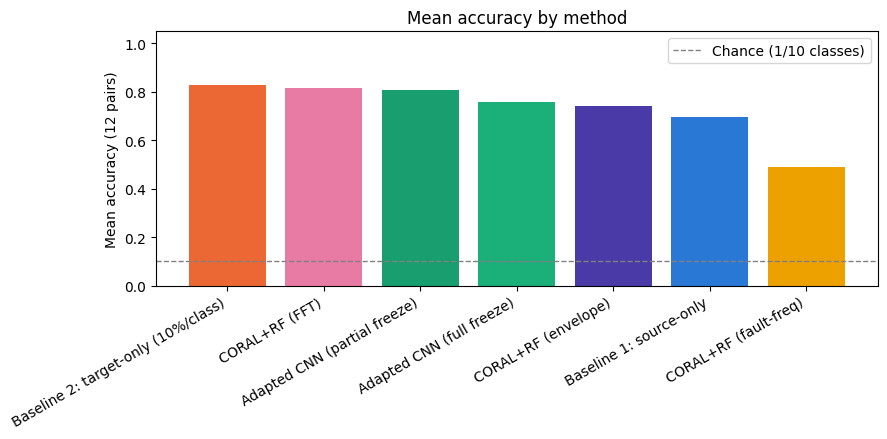

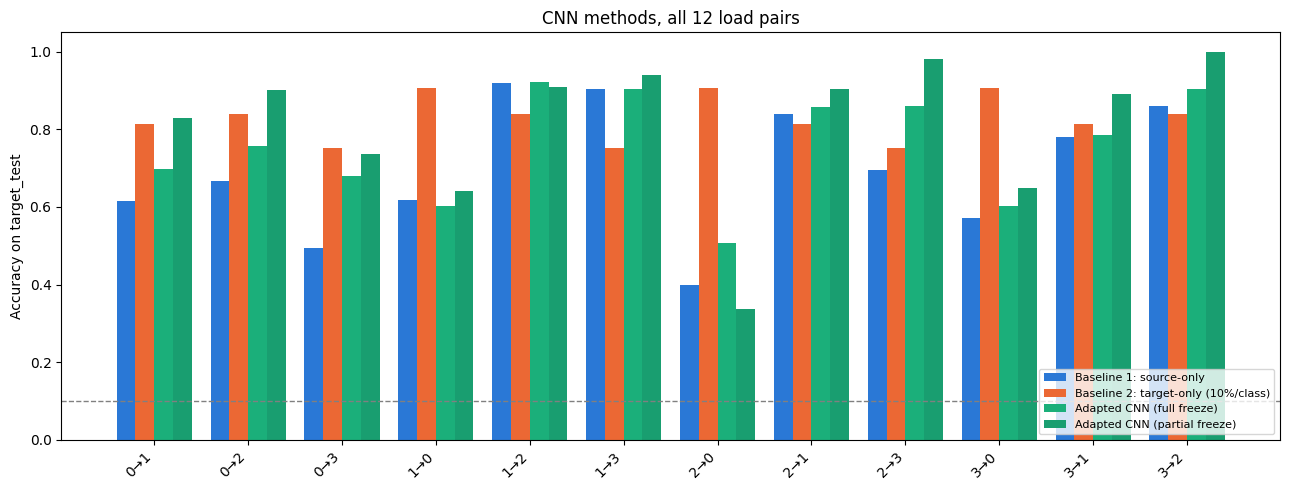

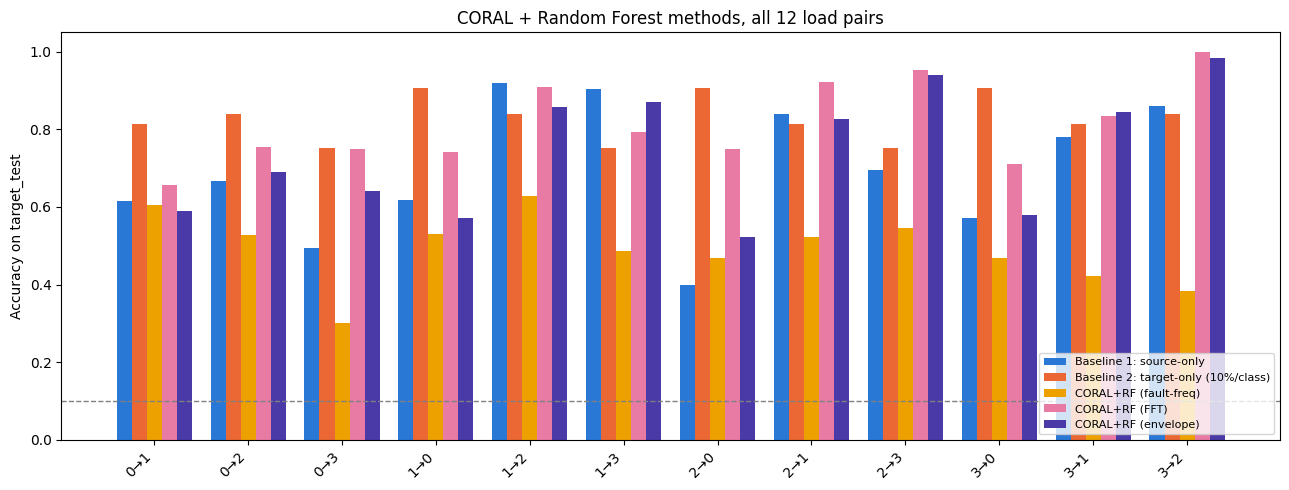

In [10]:
import matplotlib.pyplot as plt

ASSETS_DIR = "assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

# Fixed color per method — kept consistent across every chart below, not reassigned by rank/sort order.
METHOD_STYLE = {
    "baseline1_acc": ("Baseline 1: source-only", "#2a78d6"),
    "baseline2_acc": ("Baseline 2: target-only (10%/class)", "#eb6834"),
    "adapted_cnn_full_acc": ("Adapted CNN (full freeze)", "#1baf7a"),
    "adapted_cnn_partial_acc": ("Adapted CNN (partial freeze)", "#199e70"),
    "coral_rf_fault_freq_acc": ("CORAL+RF (fault-freq)", "#eda100"),
    "coral_rf_fft_acc": ("CORAL+RF (FFT)", "#e87ba4"),
    "coral_rf_envelope_acc": ("CORAL+RF (envelope)", "#4a3aa7"),
}

# --- Panel 1: mean accuracy overview, all 7 methods ---
means = comparison[list(METHOD_STYLE)].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(means)), means.values, color=[METHOD_STYLE[c][1] for c in means.index])
ax.set_xticks(range(len(means)))
ax.set_xticklabels([METHOD_STYLE[c][0] for c in means.index], rotation=30, ha="right")
ax.axhline(1 / N_CLASSES, color="gray", linewidth=1, linestyle="--", label="Chance (1/10 classes)")
ax.set_ylabel("Mean accuracy (12 pairs)")
ax.set_ylim(0, 1.05)
ax.set_title("Mean accuracy by method")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "mean_accuracy.png"), dpi=150)
plt.show()


def grouped_bar(ax, columns, title):
    pair_labels = [f"{r.source_load}→{r.target_load}" for r in comparison.itertuples()]
    x = np.arange(len(pair_labels))
    n = len(columns)
    width = 0.8 / n
    for i, col in enumerate(columns):
        label, color = METHOD_STYLE[col]
        ax.bar(x + (i - (n - 1) / 2) * width, comparison[col], width, label=label, color=color)
    ax.axhline(1 / N_CLASSES, color="gray", linewidth=1, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, rotation=45, ha="right")
    ax.set_ylabel("Accuracy on target_test")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)


# --- Panel 2: CNN methods, per pair ---
fig, ax = plt.subplots(figsize=(13, 5))
grouped_bar(ax, ["baseline1_acc", "baseline2_acc", "adapted_cnn_full_acc", "adapted_cnn_partial_acc"],
            "CNN methods, all 12 load pairs")
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "cnn_methods_per_pair.png"), dpi=150)
plt.show()

# --- Panel 3: CORAL methods, per pair ---
fig, ax = plt.subplots(figsize=(13, 5))
grouped_bar(ax, ["baseline1_acc", "baseline2_acc", "coral_rf_fault_freq_acc", "coral_rf_fft_acc", "coral_rf_envelope_acc"],
            "CORAL + Random Forest methods, all 12 load pairs")
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "coral_methods_per_pair.png"), dpi=150)
plt.show()

## 4. Consolidated results table — for the agent policy

One row per (source_load, target_load) pair, one column per representation/method — accuracy only (macro-F1 for all of these is still available in `full_comparison_results.csv` if needed). This is the hand-off artifact for the next phase: an agent choosing which method to trust for a given pair should be able to do it from this table alone.

In [11]:
POLICY_COLUMNS = {
    "baseline1_acc": "Baseline1 (no adapt)",
    "baseline2_acc": "Baseline2 (target-only)",
    "adapted_cnn_partial_acc": "CNN partial-freeze",
    "adapted_cnn_full_acc": "CNN full-freeze",
    "coral_rf_fft_acc": "CORAL+RF (fft)",
    "coral_rf_envelope_acc": "CORAL+RF (envelope)",
    "coral_rf_fault_freq_acc": "CORAL+RF (fault_freq)",
}

policy_table = comparison[["source_load", "target_load", *POLICY_COLUMNS]].rename(columns=POLICY_COLUMNS)

policy_table_path = os.path.join(DATA_DIR, "agent_policy_table.csv")
policy_table.to_csv(policy_table_path, index=False)
print(f"Saved to {policy_table_path}\n")

policy_table.round(3)

Saved to data/agent_policy_table.csv



,source_load,target_load,Baseline1 (no adapt),Baseline2 (target-only),CNN partial-freeze,CNN full-freeze,CORAL+RF (fft),CORAL+RF (envelope),CORAL+RF (fault_freq)
0,0,1,0.615,0.814,0.829,0.699,0.655,0.590,0.606
1,0,2,0.668,0.839,0.901,0.758,0.755,0.689,0.528
2,0,3,0.494,0.752,0.736,0.680,0.748,0.640,0.301
3,1,0,0.617,0.906,0.641,0.602,0.742,0.570,0.531
4,1,2,0.919,0.839,0.910,0.922,0.910,0.857,0.627
5,1,3,0.904,0.752,0.941,0.904,0.792,0.870,0.488
6,2,0,0.398,0.906,0.336,0.508,0.750,0.523,0.469
7,2,1,0.839,0.814,0.904,0.857,0.922,0.826,0.522
8,2,3,0.696,0.752,0.981,0.860,0.953,0.941,0.547
9,3,0,0.570,0.906,0.648,0.602,0.711,0.578,0.469
